# ARMA Theory

## Theoretical Properties of ARMA Models

**Author:** Miguel A. Arranz

---

### Purpose

This notebook illustrates the theoretical properties of autoregressive moving-average (ARMA) models using the `arma_theory` Python module.

Rather than estimating models from data, the objective is to understand how the model coefficients determine the behaviour of the stochastic process. Given the coefficients of an ARMA model, the notebook computes and visualizes its main theoretical properties, including:

- Causality (stationarity) conditions
- Invertibility conditions
- Detection of common AR and MA roots
- Theoretical autocorrelation function (ACF)
- Theoretical partial autocorrelation function (PACF)
- Infinite moving-average representation
- Root diagrams and other graphical summaries

The notebook is intended as a companion to the `arma_theory` library and is designed for students taking courses in Time Series Analysis and Econometric Techniques.

---

**Model convention**

Throughout this notebook we consider ARMA models of the form

$$
y_t
=
\phi_1y_{t-1}
+\cdots+
\phi_py_{t-p}
+
\varepsilon_t
+
\theta_1\varepsilon_{t-1}
+\cdots+
\theta_q\varepsilon_{t-q},
$$

or, equivalently,

$$
\phi(L)y_t=\theta(L)\varepsilon_t,
$$

where

$$
\phi(L)=1-\phi_1L-\cdots-\phi_pL^p,
$$

and

$$
\theta(L)=1+\theta_1L+\cdots+\theta_qL^q.
$$

This sign convention is used consistently throughout the library.

## Imports

In [73]:
%load_ext autoreload
%autoreload 2

import arma_theory as arma
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Testing Diagnostics

In [74]:
results = arma.arma_diagnostics(
    ar=[0.6, -0.2],
    ma=[0.5]
)

In [75]:
results

{'order': (2, 1),
 'ar': array([ 0.6, -0.2]),
 'ma': array([0.5]),
 'ar_polynomial': array([ 1. , -0.6,  0.2]),
 'ma_polynomial': array([1. , 0.5]),
 'ar_roots': array([1.5+1.6583124j, 1.5-1.6583124j]),
 'ma_roots': array([-2.+0.j]),
 'inverse_ar_roots': array([0.3-0.33166248j, 0.3+0.33166248j]),
 'inverse_ma_roots': array([-0.5-0.j]),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### AR(1), Causal

In [76]:
arma.arma_diagnostics(ar=[0.8], ma=[])

{'order': (1, 0),
 'ar': array([0.8]),
 'ma': array([], dtype=float64),
 'ar_polynomial': array([ 1. , -0.8]),
 'ma_polynomial': array([1.]),
 'ar_roots': array([1.25+0.j]),
 'ma_roots': array([], dtype=complex128),
 'inverse_ar_roots': array([0.8+0.j]),
 'inverse_ma_roots': array([], dtype=complex128),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### AR(1), Non-causal

In [77]:
arma.arma_diagnostics(ar=[1.25], ma=[])

{'order': (1, 0),
 'ar': array([1.25]),
 'ma': array([], dtype=float64),
 'ar_polynomial': array([ 1.  , -1.25]),
 'ma_polynomial': array([1.]),
 'ar_roots': array([0.8+0.j]),
 'ma_roots': array([], dtype=complex128),
 'inverse_ar_roots': array([1.25+0.j]),
 'inverse_ma_roots': array([], dtype=complex128),
 'causal': False,
 'stationary': False,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### Pure MA(1)

In [78]:
arma.arma_diagnostics(ar=[], ma=[0.7])

{'order': (0, 1),
 'ar': array([], dtype=float64),
 'ma': array([0.7]),
 'ar_polynomial': array([1.]),
 'ma_polynomial': array([1. , 0.7]),
 'ar_roots': array([], dtype=complex128),
 'ma_roots': array([-1.42857143+0.j]),
 'inverse_ar_roots': array([], dtype=complex128),
 'inverse_ma_roots': array([-0.7-0.j]),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### Non-invertible MA(1)

In [79]:
arma.arma_diagnostics(ar=[], ma=[1.5])

{'order': (0, 1),
 'ar': array([], dtype=float64),
 'ma': array([1.5]),
 'ar_polynomial': array([1.]),
 'ma_polynomial': array([1. , 1.5]),
 'ar_roots': array([], dtype=complex128),
 'ma_roots': array([-0.66666667+0.j]),
 'inverse_ar_roots': array([], dtype=complex128),
 'inverse_ma_roots': array([-1.5-0.j]),
 'causal': True,
 'stationary': True,
 'invertible': False,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### AR(2) with Complex Roots

In [80]:
arma.arma_diagnostics(ar=[0.8, -0.8], ma=[])

{'order': (2, 0),
 'ar': array([ 0.8, -0.8]),
 'ma': array([], dtype=float64),
 'ar_polynomial': array([ 1. , -0.8,  0.8]),
 'ma_polynomial': array([1.]),
 'ar_roots': array([0.5+1.j, 0.5-1.j]),
 'ma_roots': array([], dtype=complex128),
 'inverse_ar_roots': array([0.4-0.8j, 0.4+0.8j]),
 'inverse_ma_roots': array([], dtype=complex128),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

In [81]:
arma.arma_diagnostics(ar=[1.2, -0.8], ma=[])

{'order': (2, 0),
 'ar': array([ 1.2, -0.8]),
 'ma': array([], dtype=float64),
 'ar_polynomial': array([ 1. , -1.2,  0.8]),
 'ma_polynomial': array([1.]),
 'ar_roots': array([0.75+0.8291562j, 0.75-0.8291562j]),
 'ma_roots': array([], dtype=complex128),
 'inverse_ar_roots': array([0.6-0.66332496j, 0.6+0.66332496j]),
 'inverse_ma_roots': array([], dtype=complex128),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': False,
 'common_root_pairs': [],
 'minimal_representation': True,
 'root_tolerance': 1e-06}

### Common Root

In [82]:
arma.arma_diagnostics(
    ar=[0.5],
    ma=[-0.5]
)

{'order': (1, 1),
 'ar': array([0.5]),
 'ma': array([-0.5]),
 'ar_polynomial': array([ 1. , -0.5]),
 'ma_polynomial': array([ 1. , -0.5]),
 'ar_roots': array([2.+0.j]),
 'ma_roots': array([2.+0.j]),
 'inverse_ar_roots': array([0.5+0.j]),
 'inverse_ma_roots': array([0.5+0.j]),
 'causal': True,
 'stationary': True,
 'invertible': True,
 'common_roots': True,
 'common_root_pairs': [{'ar_index': 0,
   'ma_index': 0,
   'ar_root': np.complex128(2+0j),
   'ma_root': np.complex128(2+0j),
   'relative_distance': 0.0}],
 'minimal_representation': False,
 'root_tolerance': 1e-06}

## Testing Weights

In [83]:
ar = [0.8]
ma = []
arma.arma_psi_weights(ar, ma, n_terms=5)

array([1.    , 0.8   , 0.64  , 0.512 , 0.4096])

## Testing ACF/PACF

### AR(1)

In [84]:
ar = [0.8]
ma = []

gamma = arma.arma_autocovariances(
    ar,
    ma,
    n_lags=5,
)

acf = arma.arma_acf(
    ar,
    ma,
    n_lags=5,
)

pacf = arma.arma_pacf(
    ar=ar,
    ma=ma,
    n_lags=5,
)

print("Autocovariances:")
print(gamma)

print("\nACF:")
print(acf)

print("\nPACF:")
print(pacf)

Autocovariances:
[2.77777778 2.22222222 1.77777778 1.42222222 1.13777778 0.91022222]

ACF:
[1.      0.8     0.64    0.512   0.4096  0.32768]

PACF:
[ 1.00000000e+00  8.00000000e-01 -3.08395285e-16  0.00000000e+00
 -1.54197642e-16  3.08395285e-16]


In [85]:
np.allclose(
    acf,
    0.8 ** np.arange(6),
)

True

In [86]:
np.allclose(
    pacf[2:],
    0.0,
    atol=1e-10,
)

True

### MA(1)

In [87]:
acf_ma1 = arma.arma_acf(
    ar=[],
    ma=[0.5],
    n_lags=5,
)

pacf_ma1 = arma.arma_pacf(
    ar=[],
    ma=[0.5],
    n_lags=5,
)

print(acf_ma1)
print(pacf_ma1)

[1.  0.4 0.  0.  0.  0. ]
[ 1.          0.4        -0.19047619  0.09411765 -0.04692082  0.02344322]


## Asserts

### AR(1)

In [88]:
acf_ar1 = arma.arma_acf(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

pacf_ar1 = arma.arma_pacf(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

assert np.allclose(
    acf_ar1,
    0.8 ** np.arange(21),
)

assert np.allclose(
    pacf_ar1[2:],
    0.0,
    atol=1e-10,
)

### MA(1)

In [89]:
acf_ma1 = arma.arma_acf(
    ar=[],
    ma=[0.5],
    n_lags=20,
)

assert np.isclose(acf_ma1[1], 0.4)
assert np.allclose(acf_ma1[2:], 0.0)

### AR(2)

In [90]:
pacf_ar2 = arma.arma_pacf(
    ar=[0.5, 0.2],
    ma=[],
    n_lags=20,
)

assert np.allclose(
    pacf_ar2[3:],
    0.0,
    atol=1e-10,
)

## Testing ACF Graphs

### AR(1)

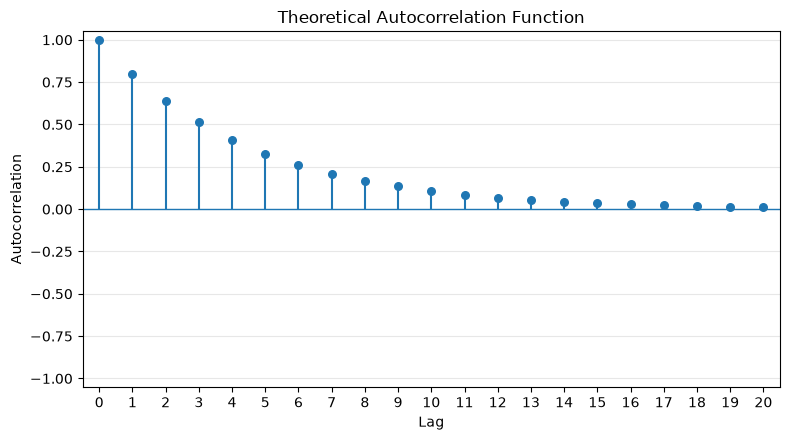

In [91]:
fig, ax = arma.plot_arma_acf(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

### MA(1)

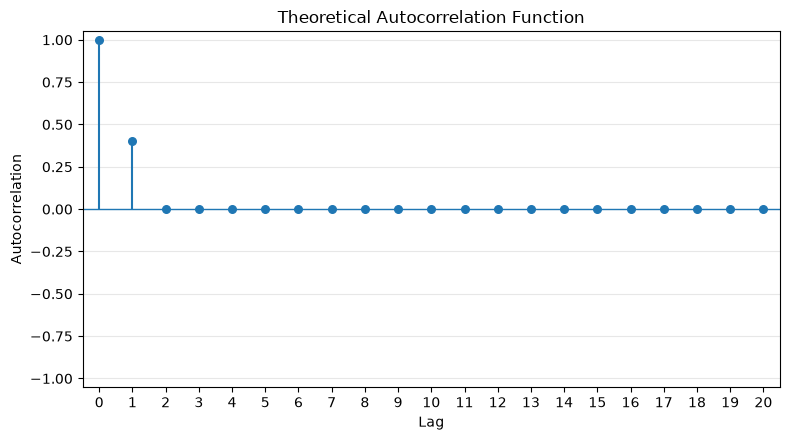

In [92]:
fig, ax = arma.plot_arma_acf(
    ar=[],
    ma=[0.5],
    n_lags=20,
)

## Testing PACF Graph

### AR(1)

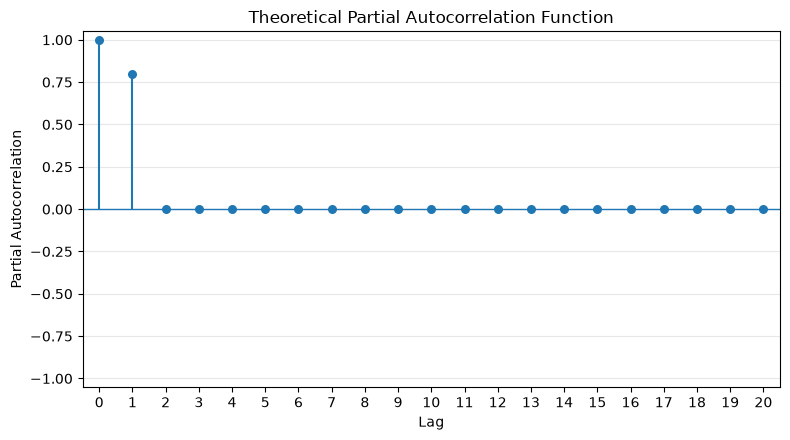

In [93]:
fig, ax = arma.plot_arma_pacf(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

### MA(1)

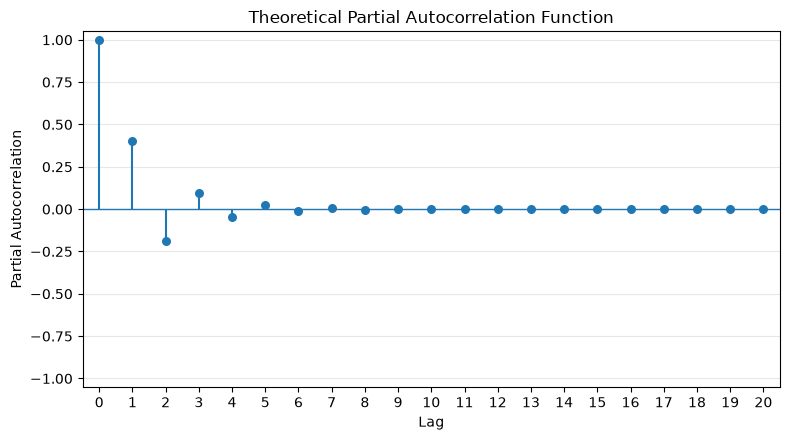

In [94]:
fig, ax = arma.plot_arma_pacf(
    ar=[],
    ma=[0.5],
    n_lags=20,
)

## Testing Combined Graphs

### AR(1)

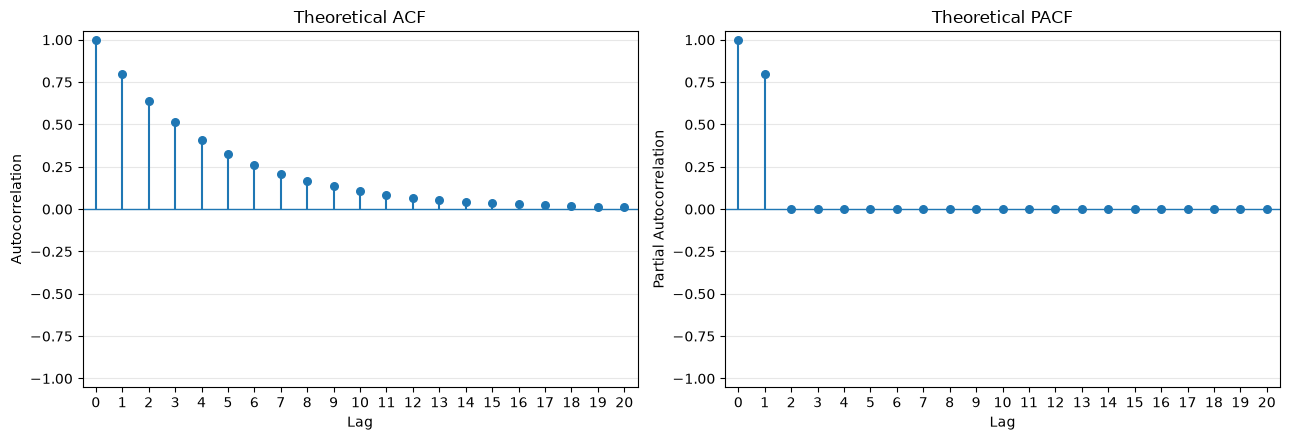

In [95]:
fig, axes = arma.plot_arma_correlations(
    ar=[0.8],
    ma=[],
    n_lags=20,
)

### MA(1)

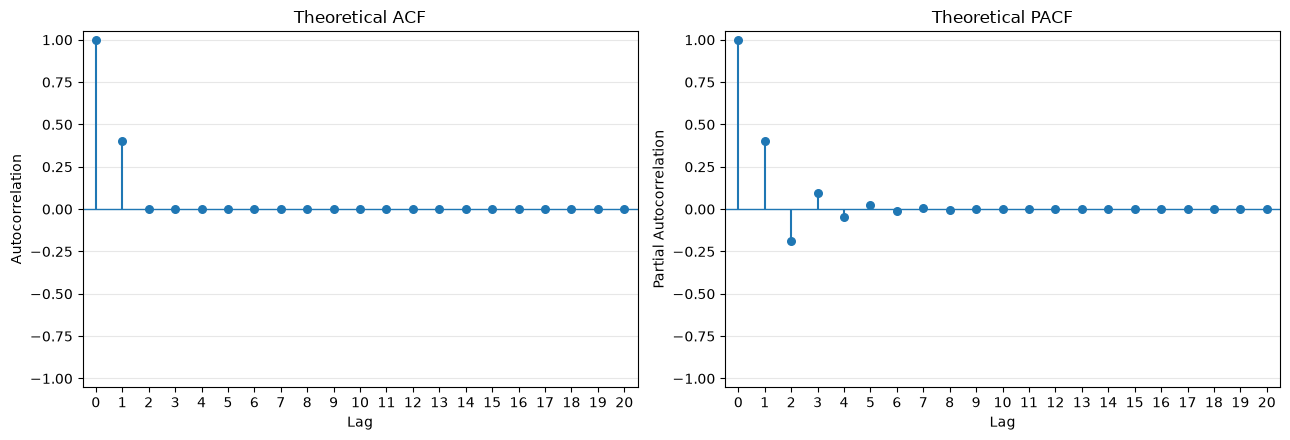

In [96]:
fig, axes = arma.plot_arma_correlations(
    ar=[],
    ma=[0.5],
    n_lags=20,
)

### ARMA(1,1)

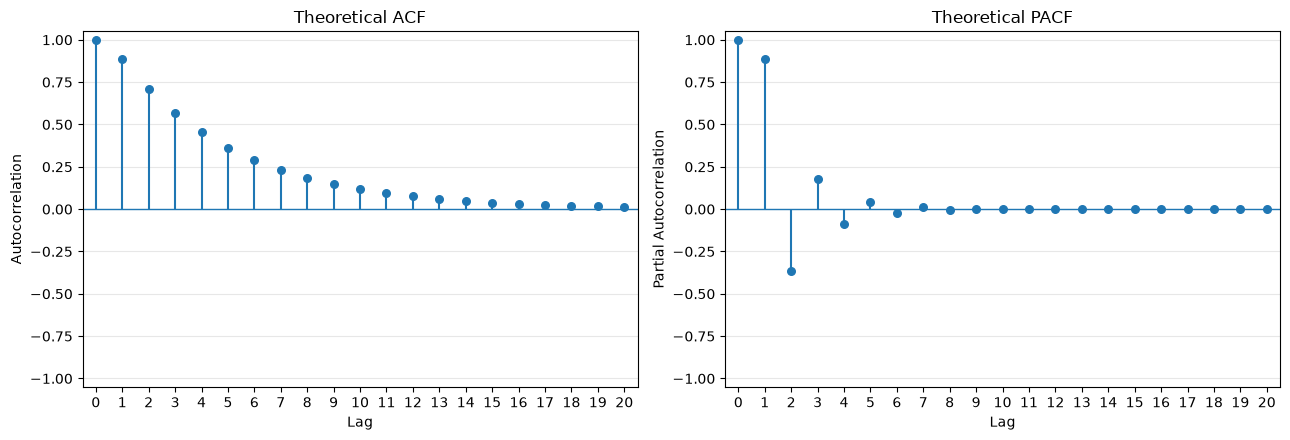

In [97]:
fig, axes = arma.plot_arma_correlations(
    ar=[0.8],
    ma=[0.5],
    n_lags=20,
)